In [1]:
%%capture
%pip install qldpc
%pip install matplotlib

## AlphaSyndrome measurement strategy

We can specify a custom stabilizer measurement circuit for running active error correction cycles by defining a new `SyndromeMeasurementStrategy`.  As an example, `AlphaSyndrome` from [arXiv:2601.12509](https://arxiv.org/abs/2601.12509) uses a Monte Carlo tree search to find stabilizer measurement circuits with reduced logical error rates.

### imports, simulation, and plotting code

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter

from qldpc import circuits, codes, decoders

%matplotlib inline

In [3]:
def run_memory_experiments(
    code: codes.CSSCode,
    strategies: Sequence[circuits.SyndromeMeasurementStrategy],
    error_rates: Sequence[float] = list(np.logspace(-4, -2, 5)),
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    **decoding_kwargs: object,
) -> list[sinter.TaskStats]:
    """Use sinter to simulate memory cycles of the given codes.

    This function ...
      1. Builds a memory experiment for each code.
      2. Adds a depolarizing noise to all gates, at the provided error rates.
      2. Wraps each noisy circuit in a `sinter.Task``.
      3. Runs batched Monte Carlo sampling with `sinter.collect`.

    Args:
        code: The code we wish to simulate.
        strategies: The syndrome measurement strategies we wish to use.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        A `sinter` stats object aggregating shots, errors, and metadata for downstream plotting.
    """
    distance = code.get_distance(bound=distance_trials)
    noise_models = {
        prob: circuits.DepolarizingNoiseModel(prob, include_idling_error=False)
        for prob in error_rates
    }

    tasks = []
    custom_decoders = {}  # each code is going to need its own decoder
    for strategy_index, strategy in enumerate(strategies):
        # Collect the components of the memory experiment.  In particular, we will need the record
        # of detectors and qubit indices.
        initialization, qec_cycle, readout, measurement_record, detector_record, qubit_ids = (
            circuits.get_memory_experiment_parts(
                code, basis=None, num_rounds=distance, syndrome_measurement_strategy=strategy
            )
        )

        # Identify detectors associated with X-type and Z-type stabilizers (parity checks).
        detectors_x = detector_record.get_events(*qubit_ids.checks_x)
        detectors_z = detector_record.get_events(*qubit_ids.checks_z)

        # Build a decoder that separately decodes X and Z sectors to predict X and Z observables.
        # Here X observables are numbered 0, 1, ..., code.dimension - 1, and Z observables are
        # numbered code.dimension, code.dimension + 1, ..., code.dimension * 2 - 1.
        decoder = decoders.SubgraphDecoder(
            (detectors_x, detectors_z),  # X/Z detectors
            (range(code.dimension), range(code.dimension, 2 * code.dimension)),  # X/Z observables
            **decoding_kwargs,
        )
        decoder_name = f"decoder_{strategy_index}"
        custom_decoders[decoder_name] = decoder

        for prob in error_rates:
            noise_model = noise_models[prob]
            noisy_circuit = initialization + noise_model.noisy_circuit(qec_cycle) + readout
            dem = noisy_circuit.detector_error_model(decompose_errors=True)
            tasks.append(
                sinter.Task(
                    circuit=noisy_circuit,
                    detector_error_model=dem,
                    decoder=decoder_name,
                    json_metadata={"label": type(strategy).__name__, "prob": prob},
                )
            )

    return sinter.collect(
        num_workers=os.cpu_count() - 2,
        max_shots=max_shots,
        max_errors=max_errors,
        tasks=tasks,
        custom_decoders=custom_decoders,
    )


def make_memory_experiment_figure(
    code: codes.CSSCode,
    strategies: Sequence[circuits.SyndromeMeasurementStrategy],
    error_rates: Sequence[float] = list(np.logspace(-4, -2, 5)),
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    figsize: tuple[int, int] = (5, 4),
    **decoding_kwargs: object,
) -> tuple[plt.Figure, plt.Axes]:
    """Use sinter to simulate memory cycles of the given codes, and plot the results.

    Args:
        code: The code we wish to simulate.
        strategies: The syndrome measurement strategies we wish to use.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        figsize: The size of the figure to produce.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        The matplotlib.pyplot figure and axis.
    """
    stats = run_memory_experiments(
        code, strategies, error_rates, max_shots, max_errors, distance_trials, **decoding_kwargs
    )

    figure, axis = plt.subplots(figsize=figsize)
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stats: stats.json_metadata["prob"],
        group_func=lambda stats: stats.json_metadata["label"],
    )

    axis.axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axis.loglog()
    axis.set_xlabel(r"physical error rate")
    axis.set_ylabel(r"logical error rate")
    axis.legend(loc="best")
    axis.grid(which="both")
    figure.tight_layout()

    return figure, axis

### Steane code

`AlphaSyndrome` is really a big-compute method.  For a small demonstration, though, we'll find a syndrome extraction circuit that is better than the default for the Steane code.  Again, to speed things up we'll use minimum-weight perfect matching (MWPM) decoder for this demo, even though the Steane code yields a non-matchable decoding graph.

Building gate schedule for X-type syndrome extraction circuit...


Scheduling gate 12 of 12: 100%|██████████████████████████████████████████████| 2/2 [00:00<00:00, 40.50it/s]


Building gate schedule for Z-type syndrome extraction circuit...


Scheduling gate 12 of 12: 100%|████████████████████████████████████████████| 43/43 [00:01<00:00, 40.34it/s]


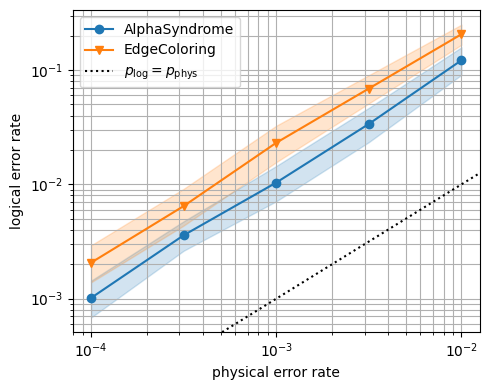

In [4]:
code = codes.SteaneCode()
decoding_kwargs = dict(with_MWPM=True, ignore_non_graphlike_errors=True)

noise_model = circuits.DepolarizingNoiseModel(10e-3)  # noise model used to train AlphaSyndrome\
decoder = decoders.SinterDecoder(**decoding_kwargs)
strategies = [
    circuits.EdgeColoring(),
    circuits.AlphaSyndrome(noise_model, decoder=decoder),
]

make_memory_experiment_figure(code, strategies, **decoding_kwargs)
plt.show()